In [14]:
PATH_TRAINING = "/lustre/fsn1/projects/rech/jmo/ubc65oh/trainings/isprs_supervised_forecast_v6/s2s1/cd_mm_sits.layers.cosattention.TimeCosFormerAttention_True/seed_1/model_layers_3/forec_3/2025-11-22/00-56-27-387673"  # "/lustre/fsn1/projects/rech/jmo/ubc65oh/trainings/isprs_supervised_forecast_v6/s2s1//cd_mm_sits.layers.cosattention.TimeCosFormerAttention_True/seed_2/model_layers_3/forec_3/2025-11-22/00-56-14-102886"

In [15]:
import copy
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from einops import rearrange
from hydra.utils import instantiate
from omegaconf import OmegaConf
from torchmetrics import MetricCollection

from cd_mm_sits.data.utils import from_int2date
from cd_mm_sits.metrics.reconstruction import MaskedMSEMetric
from cd_mm_sits.model.utils import cat_nested_along_time

In [16]:
model_name = Path(PATH_TRAINING).parts[-3]
print(model_name)

forec_3


In [17]:
from lightning.pytorch import seed_everything


def remove_compiled_prefix(state_dict):
    """Remove '_orig_mod.' prefix from state dict keys added by torch.compile()."""
    new_state_dict = {}
    for key, value in state_dict.items():
        new_key = key.replace("_orig_mod.", "")
        new_state_dict[new_key] = value
    return new_state_dict


def load_pretrained_model(path_training, max_len=40):
    model_name = Path(path_training).parts[-6] + "_" + Path(path_training).parts[-5]
    config_path = Path(path_training).joinpath(".hydra").joinpath("config.yaml")
    # ckpt_path=get_best_checkpoint(Path(PATH_TRAINING),metric="best")
    ckpt_path = Path(path_training).joinpath(
        "lightning_logs/version_0/checkpoints/best.ckpt"
    )
    ckpt_path.exists()
    config = OmegaConf.load(config_path)
    model = instantiate(config.model)
    train_config = instantiate(
        config.train.train_config,
        loss=instantiate(config.train.train_config.loss),
        metrics=MetricCollection(
            {"mse_s2": MaskedMSEMetric(mod="s2"), "mse_s1": MaskedMSEMetric(mod="s1")}
        ),
    )

    # checkpoint = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    # print(checkpoint["state_dict"])
    seed_everything(config.seed, workers=True)
    checkpoint = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    checkpoint["state_dict"] = remove_compiled_prefix(checkpoint["state_dict"])
    pl_module = instantiate(
        config.lightning_module,
        model=model,
        train_config=train_config,
        shallow_forecaster=instantiate(config.lightning_module.shallow_forecaster),
        compile=False,
    )
    pl_module.load_state_dict(checkpoint["state_dict"], strict=True)

    # pl_module = instantiate(config.lightning_module,model=instantiate(config.model),shallow_forecaster=instantiate(config.lightning_module.shallow_forecaster),train_config=train_config)#MonoMForecast (model=model, train_config=train_config,shallow_forecaster=instantiate(config.lightning_mo)
    # pl_module=pl_module.load(checkpoint["state_dict"])
    # pl_module=pl_module.load_from_checkpoint(ckpt_path,model=model,shallow_forecaster=instantiate(config.lightning_module.shallow_forecaster),train_config=instantiate(train_config),compile=True)
    # pl_module.model.load_state_dict(torch.load(ckpt_path, weights_only=True,map_location=torch.device('cpu')))()
    pl_module.freeze()
    pl_module.eval()
    datamodule = instantiate(
        config.datamodule,
        num_workers=0,
        prefetch_factor=None,
        persistent_workers=False,
        max_len=max_len,
    )
    datamodule.setup("test")
    return pl_module, datamodule, model_name

In [18]:
pl_module, datamodule, model_name = load_pretrained_model(PATH_TRAINING)

[rank: 0] Seed set to 1


MMForecastDatase/n° of samples: train: 443 val: 95 test: 96
Loaded weather variables: 
 /lustre/fsn1/projects/rech/jmo/commun/datasets/pretraining/all_sites_mini_agera5.parquet 
Loaded weather variables: 
 /lustre/fsn1/projects/rech/jmo/commun/datasets/pretraining/all_sites_mini_agera5.parquet 
Loaded weather variables: 
 /lustre/fsn1/projects/rech/jmo/commun/datasets/pretraining/all_sites_mini_agera5.parquet 


In [19]:
test_dataloader = datamodule.test_dataloader()
iter_dataloader = iter(test_dataloader)

In [20]:
import numpy as np
from matplotlib.colors import BoundaryNorm


class CustomNorm(BoundaryNorm):
    def __init__(self, boundaries):
        boundaries = [-1.5, -0.5] + list(np.linspace(0, 1, 256))
        super().__init__(boundaries, ncolors=len(boundaries) - 1)


def normalize(p, vmin, vmax):
    p = (p - vmin) / (vmax - vmin)
    p = 255 * np.clip(p, 0.0, 1.0)
    return p.astype(np.uint8)


def show_results_mm(batch, out, idx_sort, mm_times, band_s1=0, figsize=(70, 5)):
    s1_len = batch.s1.time[0, ...].shape[0]
    s2_len = batch.s2.time[0, ...].shape[0]
    # pred=outputs.out
    # label = outputs.label.cpu()
    bands = [2, 1, 0]
    fig, ax = plt.subplots(2, s1_len + s2_len - 1, figsize=figsize)
    vmin, vmax = np.quantile(
        batch.s2.content[0, :, bands, ...].detach().cpu().numpy(), (0.01, 0.9)
    )
    for i in range(0, s1_len + s2_len - 1):
        idx_img = idx_sort[i]
        ax[0, i].set_title(str(from_int2date(mm_times[0, idx_img].item()).date()))
        if int(idx_img) >= s1_len:
            ax[0, i].imshow(
                normalize(
                    rearrange(
                        batch.s2.content[0, idx_img - s1_len, bands, ...],
                        "c h w -> h w c",
                    )
                    .detach()
                    .cpu()
                    .numpy(),
                    vmin,
                    vmax,
                )
            )
            if i > 5:
                idx_s2 = torch.where(out.idx_s2_trg == idx_img - s1_len)[0].item()
                pred_show = rearrange(out.pred_s2[idx_s2, bands, ...], "c h w -> h w c")
                ax[1, i].imshow(normalize(pred_show.detach().cpu().numpy(), vmin, vmax))
        else:
            ax[0, i].set_title(str(from_int2date(mm_times[0, idx_img].item()).date()))
            ax[0, i].imshow(batch.s1.content[0, idx_img, band_s1, ...])
            if i > 5:
                idx_s1 = torch.where(out.idx_s1_trg == idx_img)[0].item()
                ax[1, i].imshow(out.pred_s1[idx_s1, band_s1, ...])
            # ax[1,t].imshow(label[0,t,...],norm=norm,cmap=cmap)
        ax[0, i].set_axis_off()
        ax[1, i].set_axis_off()
    return fig

In [47]:
batch = next(iter_dataloader)

In [48]:
copy_batch = copy.deepcopy(batch)
norm_batch = datamodule.on_after_batch_transfer(batch, 0)
outputs = pl_module.forward(norm_batch, need_weights=False)
mm_times = cat_nested_along_time(batch.s1.time, batch.s2.time)
idx = torch.argsort(mm_times[0, ...], dim=-1)  # B,T
s1_len = batch.s1.time[0, ...].shape[0]
s2_len = batch.s2.time.shape[1]

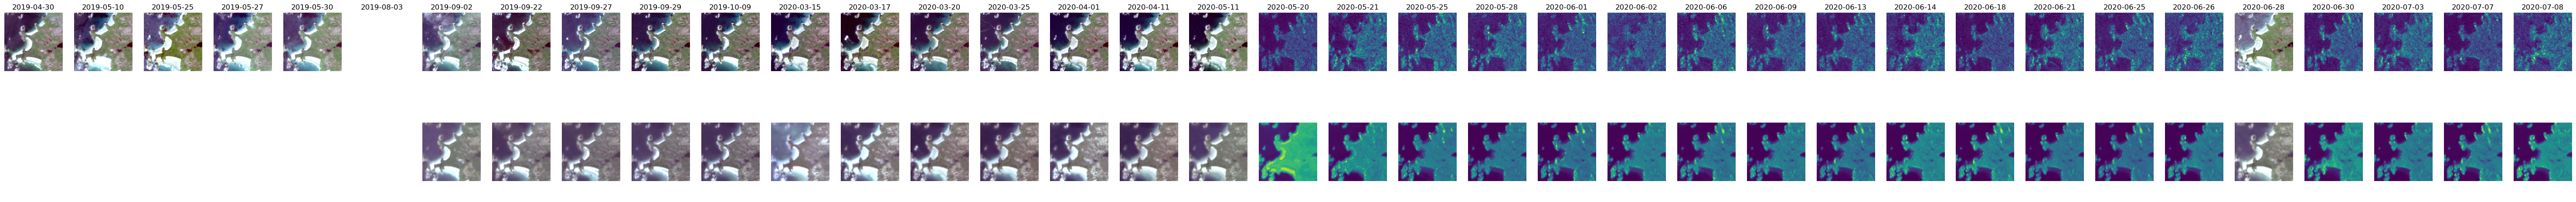

In [49]:
fig = show_results_mm(
    norm_batch, outputs, idx, mm_times, 0, figsize=(mm_times[0, ...].shape[0] * 2, 6)
)

In [43]:
fig.savefig("isprs_fixed_1.pdf")

In [20]:
out = pl_module.test_step(norm_batch, 0)

/lustre/fswork/projects/rech/jmo/ubc65oh/code/cd_mm_sits/.pixi/envs/default/lib/python3.13/site-packages/lightning/pytorch/core/module.py:449: You are trying to `self.log()` but the `self.trainer` reference is not registered on the model yet. This is most likely because the model hasn't been passed to the `Trainer`


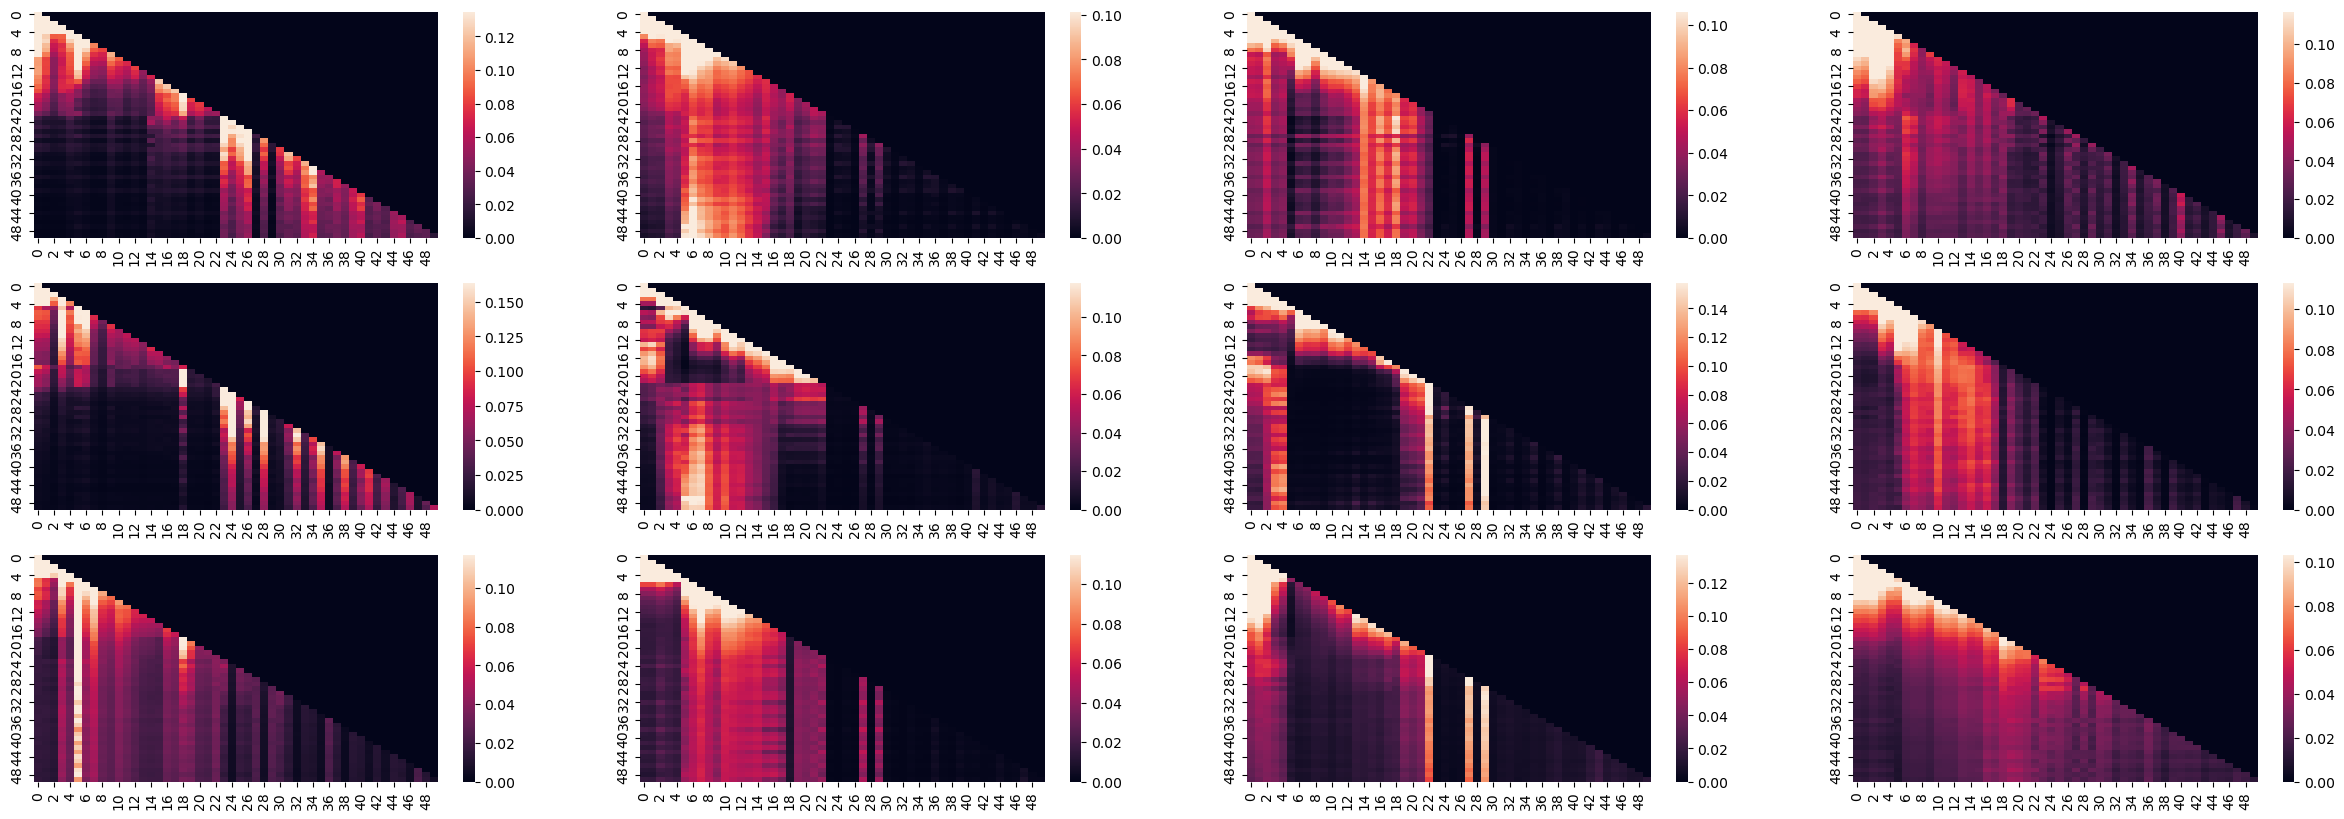

In [172]:
import seaborn as sns

weight = outputs.weights
fig, ax = plt.subplots(3, weight[0].shape[1], figsize=(30, 10))
for l in range(3):
    for h in range(weight[0].shape[1]):
        attn_mean = torch.mean(outputs.weights[l][:, h, ...], dim=0)
        sns.heatmap(attn_mean, ax=ax[l, h], robust=True)
        ax[l, h].grid(False)
# fig

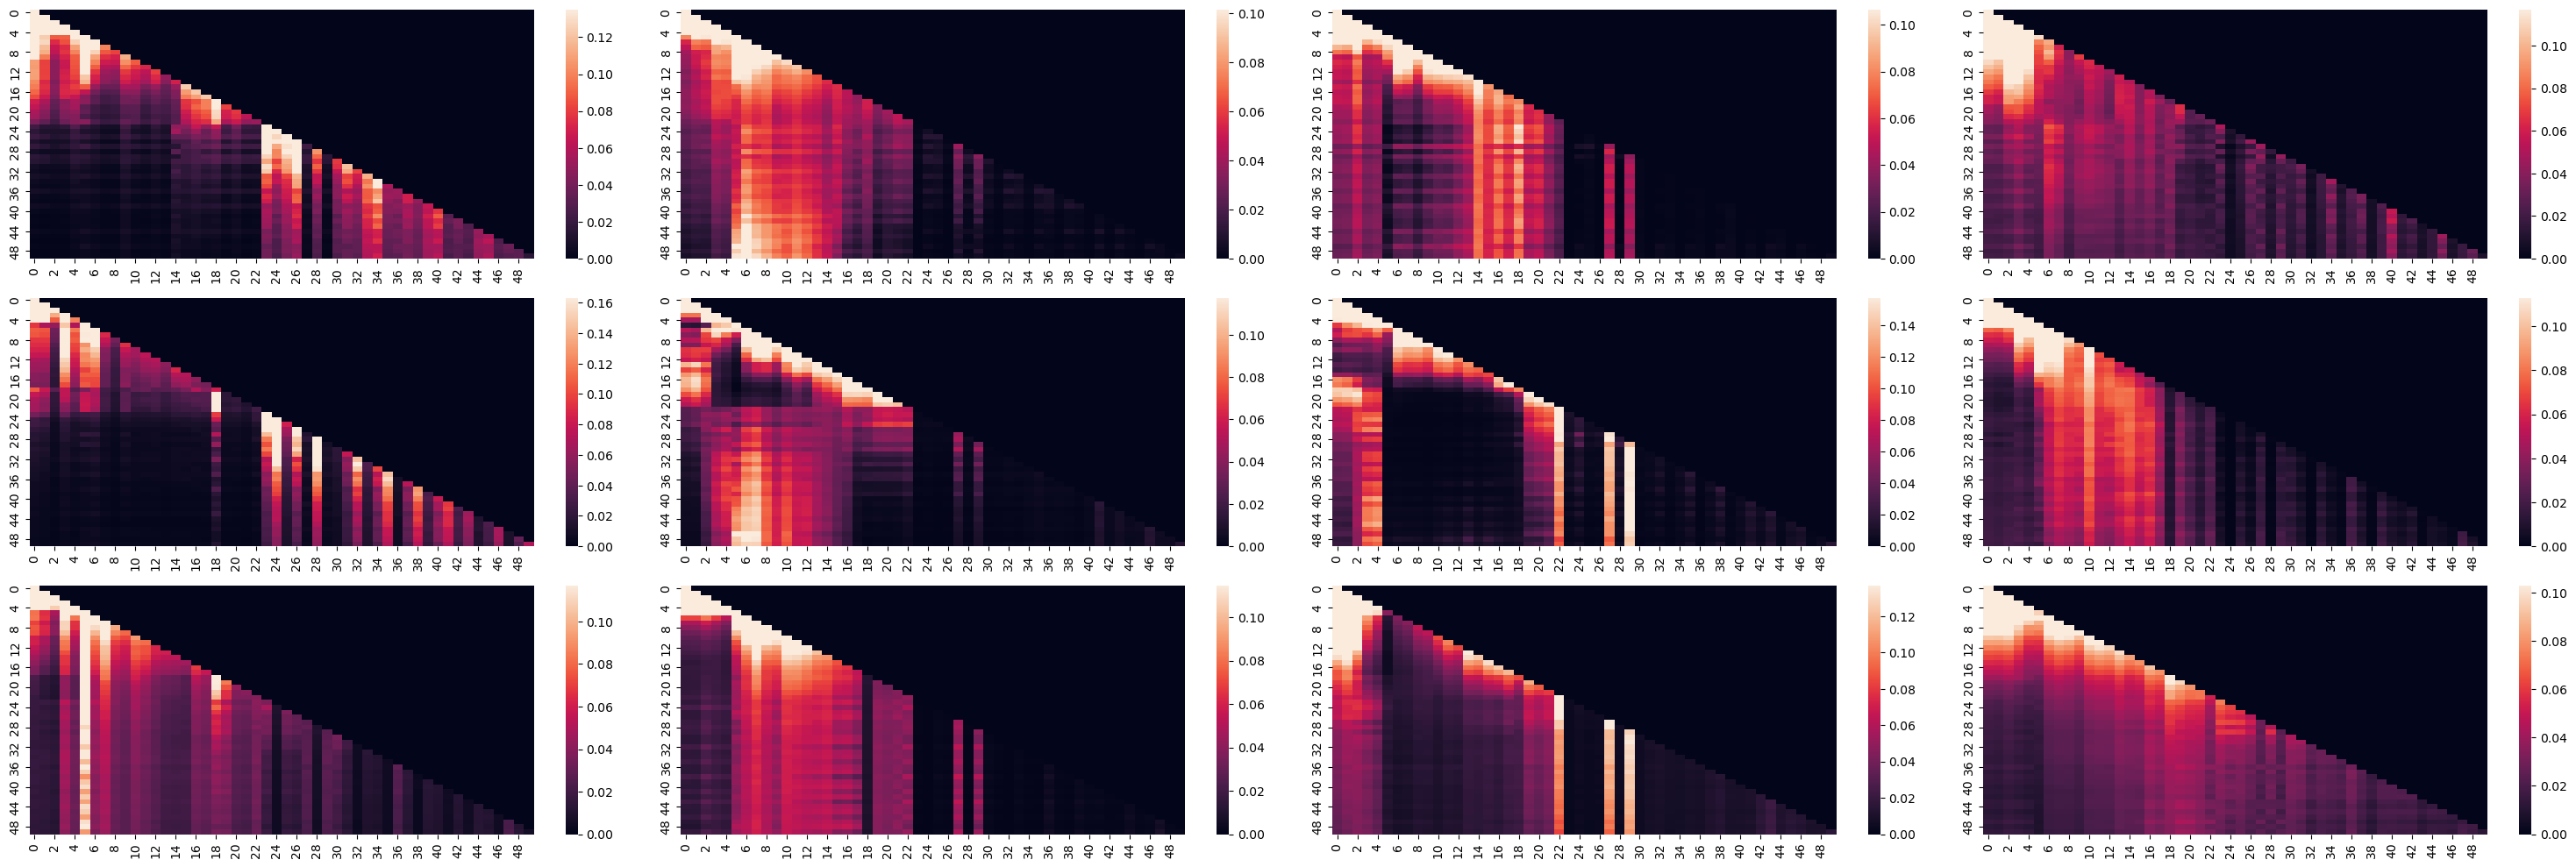

In [173]:
fig.tight_layout()
fig

In [14]:
fig.savefig(f"mm_attn_{model_name}.pdf")